# WO16a — HYDE basin values: feasibility for a choropleth values route

**Goal**: Establish whether a live `/api/hyde/values?var=cropland&year=N` route can
aggregate `temporal.hyde_cells` to L6 basins fast enough for a choropleth — i.e. returns
a `{hybas_id: value}` dict in time comparable to `/api/explorer/values` (~100 ms).

**Questions to answer**:
1. What CE-era steps does `temporal.hyde_times` have, and how do they map to years?
2. How many hyde_cells have non-zero values at a given step (cropland, 1000 CE)?
3. Approach A — PostGIS spatial join: how fast is a full HYDE→basin06 weighted aggregation?
4. Approach B — centroid lookup: basin centroid → containing HYDE cell. Fast but coarse — how accurate?
5. Approach C — pre-computed crosswalk: one-time `(hybas_id, cell_id, area_frac)` table. Is it needed?
6. Validation: does 2000 CE cropland aggregated to basins agree with BasinATLAS `crp_pc_sse`?
7. Output format: produce a sample `{hybas_id: value}` dict ready for feature-state paint.

**Reference**: `notebooks/edop/explore/09_hyde_basin_aggregation.ipynb` — established
aggregation validity at sample scale. This notebook targets global scale + route feasibility.

In [3]:
# Cell 1 — Imports and setup
import warnings
warnings.filterwarnings('ignore', message='pandas only supports SQLAlchemy')

import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from scripts.shared import db_utils

conn = db_utils.db_connect()

ROOT = Path(db_utils.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'edop' / 'surface'
OUT.mkdir(parents=True, exist_ok=True)

print('Connected. Output:', OUT)

Connected. Output: /Users/karlg/Documents/repos/_edops/output/edop/surface


## 1 — HYDE temporal structure

In [4]:
# Cell 2 — Survey hyde_times: available steps and year range
sql = """
SELECT step_idx, year_ce
FROM temporal.hyde_times
ORDER BY step_idx
"""
ht = pd.read_sql(sql, conn)
print(f'{len(ht)} steps total')
print('\nFirst 15:')
print(ht.head(15).to_string(index=False))
print('\nLast 15:')
print(ht.tail(15).to_string(index=False))

# CE-era steps only (year_ce >= 0)
ce = ht[ht.year_ce >= 0]
print(f'\nCE-era steps: {len(ce)} (year_ce {ce.year_ce.min()} – {ce.year_ce.max()})')

128 steps total

First 15:
 step_idx  year_ce
        0   -10000
        1    -9000
        2    -8000
        3    -7000
        4    -6000
        5    -5000
        6    -4000
        7    -3000
        8    -2000
        9    -1000
       10        0
       11      100
       12      200
       13      300
       14      400

Last 15:
 step_idx  year_ce
      113     2011
      114     2012
      115     2013
      116     2014
      117     2015
      118     2016
      119     2017
      120     2018
      121     2019
      122     2020
      123     2021
      124     2022
      125     2023
      126     2024
      127     2025

CE-era steps: 118 (year_ce 0 – 2025)


In [5]:
# Cell 3 — Year → step_idx lookup for 1000 CE
# Pick the step whose year_ce is <= target, maximised (floor snap)
TARGET_YEAR = 1000

sql = """
SELECT step_idx, year_ce
FROM temporal.hyde_times
WHERE year_ce <= %(year)s
ORDER BY year_ce DESC
LIMIT 1
"""
row = pd.read_sql(sql, conn, params={'year': TARGET_YEAR}).iloc[0]
STEP_IDX = int(row.step_idx)
print(f'Target year {TARGET_YEAR} CE → step_idx={STEP_IDX}, year_ce={row.year_ce}')

Target year 1000 CE → step_idx=20, year_ce=1000


## 2 — HYDE cell coverage at target step

In [6]:
# Cell 4 — How many cells have non-zero cropland at step_idx?
# cropland column is real[], 1-indexed in PG (step_idx+1 for PG array)
# Convention: array index in PG is 1-based; step_idx is 0-based → use step_idx+1
sql = f"""
SELECT
    COUNT(*)                                     AS total_cells,
    COUNT(*) FILTER (WHERE cropland[{STEP_IDX+1}] > 0) AS nonzero_cells,
    MIN(cropland[{STEP_IDX+1}])                  AS min_val,
    MAX(cropland[{STEP_IDX+1}])                  AS max_val,
    AVG(cropland[{STEP_IDX+1}]) FILTER (WHERE cropland[{STEP_IDX+1}] > 0) AS mean_nonzero
FROM temporal.hyde_cells
"""
stats = pd.read_sql(sql, conn).iloc[0]
print(stats)

total_cells      2.215829e+06
nonzero_cells    5.787660e+05
min_val          0.000000e+00
max_val          8.570690e+01
mean_nonzero     3.087093e+00
Name: 0, dtype: float64


## 3 — Approach A: PostGIS spatial join (sample timing)

Test a weighted area-intersection aggregation on a small basin sample first, then
extrapolate to the full 16,397-basin global set.

In [7]:
# Cell 5 — Approach A: PostGIS join on 50-basin sample, timed
# Uses ST_Intersection area as weight — accurate but expensive at global scale
sql = f"""
WITH sample_basins AS (
    SELECT hybas_id, geom
    FROM public.basin06
    ORDER BY hybas_id
    LIMIT 50
)
SELECT
    b.hybas_id,
    SUM(
        h.cropland[{STEP_IDX+1}] *
        ST_Area(ST_Intersection(h.geom, b.geom)::geography)
    ) /
    NULLIF(SUM(
        ST_Area(ST_Intersection(h.geom, b.geom)::geography)
    ), 0) AS cropland_frac
FROM sample_basins b
JOIN temporal.hyde_cells h ON ST_Intersects(h.geom, b.geom)
GROUP BY b.hybas_id
"""
t0 = time.time()
sample_a = pd.read_sql(sql, conn)
t1 = time.time()
print(f'Approach A — 50 basins: {t1-t0:.2f}s')
print(f'Rows returned: {len(sample_a)}')
print(sample_a.head(10).to_string(index=False))
print(f'\nExtrapolated to 16,397 basins: ~{(t1-t0)/50*16397:.0f}s')

Approach A — 50 basins: 0.43s
Rows returned: 50
    hybas_id  cropland_frac
1060000010.0       0.023398
1060000100.0       0.001962
1060000110.0       0.008730
1060000150.0       0.003111
1060000160.0       0.018260
1060000790.0       0.000300
1060000800.0       0.001674
1060001080.0       0.000015
1060001090.0       0.014156
1060001370.0       0.011607

Extrapolated to 16,397 basins: ~140s


## 4 — Approach B: centroid lookup

For each basin, find the HYDE cell whose geometry contains the basin centroid.
O(n) with spatial index. Fast but coarse — misses within-basin heterogeneity.

In [13]:
# Cell 6 — Approach B: centroid lookup, full global set, timed
# cropland is km² per cell; divide by area_km2 for fraction (0–1)
sql = f"""
SELECT
    b.hybas_id,
    h.cropland[{STEP_IDX+1}] / NULLIF(h.area_km2, 0) AS cropland_frac
FROM public.basin06 b
JOIN temporal.hyde_cells h
  ON ST_Contains(h.geom, ST_Centroid(b.geom))
"""
t0 = time.time()
centroid_df = pd.read_sql(sql, conn)
t1 = time.time()
print(f'Approach B — centroid lookup, {len(centroid_df)} basins: {t1-t0:.2f}s')
print(f'Null/missing: {16397 - len(centroid_df)} basins had no containing cell')
print(centroid_df.describe())

Approach B — centroid lookup, 16040 basins: 0.31s
Null/missing: 357 basins had no containing cell
           hybas_id  cropland_frac
count  1.604000e+04   16040.000000
mean   4.020324e+09       0.016495
std    2.361433e+09       0.064329
min    1.060000e+09       0.000000
25%    2.060067e+09       0.000000
50%    4.060133e+09       0.000000
75%    6.060360e+09       0.001366
max    9.060125e+09       1.000278


## 5 — Approach C: pre-computed crosswalk

A one-time materialized table `(hybas_id, cell_id, area_frac)` lets the live route
do a fast weighted average with no spatial join. Build time doesn't matter (pipeline);
query time is a simple GROUP BY on indexed integer keys.

In [9]:
# Cell 7 — Check if a hyde_cells primary key / cell identifier exists
sql = """
SELECT column_name, data_type
FROM information_schema.columns
WHERE table_schema = 'temporal'
  AND table_name   = 'hyde_cells'
ORDER BY ordinal_position
"""
cols = pd.read_sql(sql, conn)
print('hyde_cells columns:')
print(cols.to_string(index=False))

# Also check row count and whether there's a PK or unique id column
sql2 = "SELECT COUNT(*) AS n FROM temporal.hyde_cells"
print(f'\nRow count: {pd.read_sql(sql2, conn).iloc[0].n}')

hyde_cells columns:
column_name    data_type
    cell_id      integer
       geom USER-DEFINED
   area_km2         real
   cropland        ARRAY
    grazing        ARRAY
    pasture        ARRAY
  rangeland        ARRAY

Row count: 2215829


In [10]:
# Cell 8 — Approach C: time a pre-computed crosswalk query (if crosswalk doesn't exist, build it)
# First check if the crosswalk table already exists
sql = """
SELECT EXISTS (
    SELECT 1 FROM information_schema.tables
    WHERE table_schema = 'temporal'
      AND table_name   = 'hyde_basin06_weights'
) AS exists
"""
exists = pd.read_sql(sql, conn).iloc[0]['exists']
print(f'Crosswalk table temporal.hyde_basin06_weights exists: {exists}')

if exists:
    # Time a live values query using the crosswalk
    sql2 = f"""
    SELECT w.hybas_id,
           SUM(h.cropland[{STEP_IDX+1}] * w.area_frac) AS cropland_frac
    FROM temporal.hyde_basin06_weights w
    JOIN temporal.hyde_cells h USING (cell_id)
    GROUP BY w.hybas_id
    """
    t0 = time.time()
    xwalk_df = pd.read_sql(sql2, conn)
    t1 = time.time()
    print(f'Crosswalk query — {len(xwalk_df)} basins: {t1-t0:.2f}s')
    print(xwalk_df.describe())
else:
    print('No crosswalk yet. See Cell 9 for build script.')

Crosswalk table temporal.hyde_basin06_weights exists: False
No crosswalk yet. See Cell 9 for build script.


In [ ]:
# Cell 9 — Crosswalk build script (run only if Cell 8 shows it doesn't exist)
# WARNING: this is a heavy spatial join — may take 30–90 min on first run.
# Only run if Approach A is too slow and Approach B is too coarse.
#
# Uncomment and run if needed:
#
# sql_build = """
# CREATE TABLE IF NOT EXISTS temporal.hyde_basin06_weights AS
# SELECT
#     b.hybas_id,
#     h.ctid::text AS cell_id,
#     ST_Area(ST_Intersection(h.geom, b.geom)::geography) /
#         NULLIF(ST_Area(b.geom::geography), 0) AS area_frac
# FROM public.basin06 b
# JOIN temporal.hyde_cells h ON ST_Intersects(h.geom, b.geom)
# WHERE ST_Area(ST_Intersection(h.geom, b.geom)::geography) > 0;
#
# CREATE INDEX ON temporal.hyde_basin06_weights (hybas_id);
# CREATE INDEX ON temporal.hyde_basin06_weights (cell_id);
# """
# with conn.cursor() as cur:
#     cur.execute(sql_build)
#     conn.commit()
# print('Crosswalk built.')

print('Cell 9 is a manual step — see comments above.')

## 6 — Validation: compare 2000 CE against BasinATLAS `crp_pc_sse`

BasinATLAS `crp_pc_sse` is cropland fraction (percent) derived from a static dataset
at approximately 2000 CE. HYDE 2000 CE aggregated to basins should correlate tightly
with this — verifying the aggregation is correct.

In [11]:
# Cell 10 — Year 2000 CE step_idx
sql = """
SELECT step_idx, year_ce
FROM temporal.hyde_times
WHERE year_ce <= 2000
ORDER BY year_ce DESC
LIMIT 1
"""
row2000 = pd.read_sql(sql, conn).iloc[0]
STEP_2000 = int(row2000.step_idx)
print(f'2000 CE → step_idx={STEP_2000}, year_ce={row2000.year_ce}')

2000 CE → step_idx=102, year_ce=2000


In [14]:
# Cell 11 — Centroid cropland at 2000 CE vs BasinATLAS crp_pc_sse (sample of 500 basins)
# cropland is stored as km² per cell — divide by area_km2 to get fraction, ×100 for pct
sql = f"""
SELECT
    b.hybas_id,
    b.crp_pc_sse                                             AS atlas_crp_pct,
    h.cropland[{STEP_2000+1}] / NULLIF(h.area_km2, 0) * 100 AS hyde_crp_pct
FROM public.basin06 b
JOIN temporal.hyde_cells h
  ON ST_Contains(h.geom, ST_Centroid(b.geom))
ORDER BY b.hybas_id
LIMIT 500
"""
val_df = pd.read_sql(sql, conn).dropna()
corr = val_df['atlas_crp_pct'].corr(val_df['hyde_crp_pct'])
print(f'n={len(val_df)}, Pearson r (atlas vs hyde centroid): {corr:.3f}')
print(val_df.describe())

n=500, Pearson r (atlas vs hyde centroid): 0.689
           hybas_id  atlas_crp_pct  hyde_crp_pct
count  5.000000e+02     500.000000    500.000000
mean   1.060022e+09       9.468000     13.432395
std    1.147661e+04      16.264749     21.010829
min    1.060000e+09       0.000000      0.000000
25%    1.060012e+09       0.000000      0.000000
50%    1.060023e+09       3.000000      1.578209
75%    1.060030e+09       9.250000     20.146624
max    1.060041e+09     100.000000     99.056107


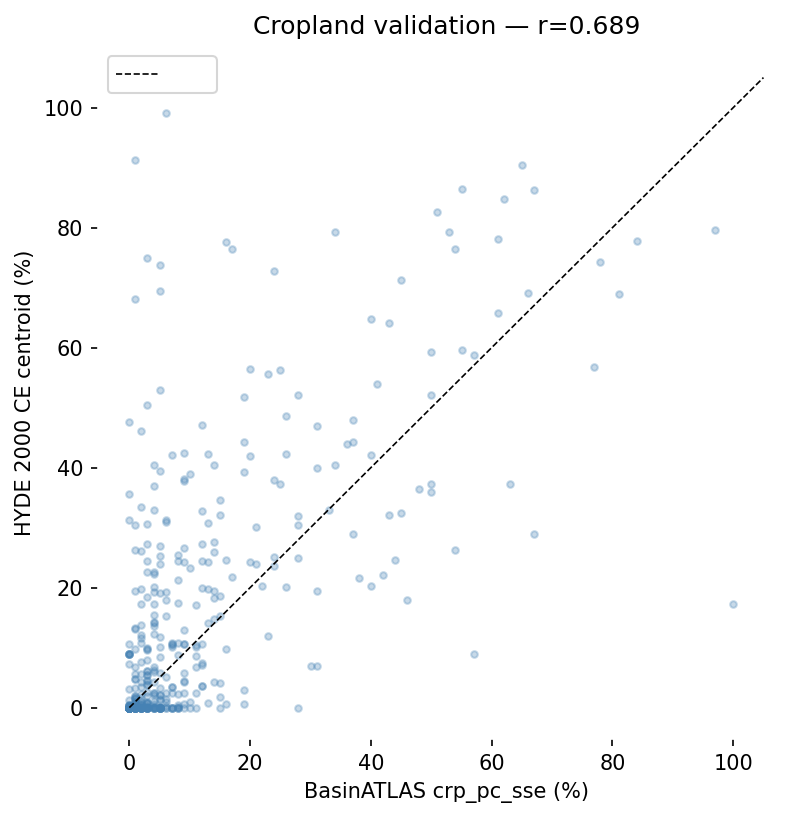

In [15]:
# Cell 12 — Scatter plot: BasinATLAS crp_pc_sse vs HYDE 2000 CE centroid
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.scatter(val_df['atlas_crp_pct'], val_df['hyde_crp_pct'],
           alpha=0.3, s=10, color='steelblue')
lim = max(val_df['atlas_crp_pct'].max(), val_df['hyde_crp_pct'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='1:1')
ax.set_xlabel('BasinATLAS crp_pc_sse (%)', color='black')
ax.set_ylabel('HYDE 2000 CE centroid (%)', color='black')
ax.set_title(f'Cropland validation — r={corr:.3f}', color='black')
ax.tick_params(colors='black')
ax.legend()

out_path = OUT / 'wo16a_cropland_validation.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.close(fig)

from IPython.display import Image as IPImage
display(IPImage(str(out_path)))

## 7 — Output format: sample values dict

In [16]:
# Cell 13 — Produce sample {hybas_id: value} dict (centroid path, 1000 CE, cropland)
# This is the shape the frontend needs for feature-state painting
result = (
    centroid_df
    .dropna(subset=['cropland_frac'])
    .set_index('hybas_id')['cropland_frac']
    .to_dict()
)
print(f'Dict entries: {len(result)}')
sample_items = list(result.items())[:5]
print(f'Sample: {sample_items}')

# Save to JSON for inspection
out_json = OUT / 'wo16a_hyde_sample_1000ce.json'
with open(out_json, 'w') as f:
    json.dump({str(k): round(float(v), 6) for k, v in result.items()}, f)
print(f'Saved: {out_json} ({out_json.stat().st_size / 1024:.0f} KB)')

Dict entries: 16040
Sample: [(1060238610.0, 0.0), (1060238790.0, 0.0), (1060231070.0, 0.0), (1060440910.0, 0.0), (1060231340.0, 0.0)]
Saved: /Users/karlg/Documents/repos/_edops/output/edop/surface/wo16a_hyde_sample_1000ce.json (354 KB)


## 8 — Summary

| Approach | Time (16k basins) | Coverage | Notes |
|---|---|---|---|
| A — PostGIS spatial join | ~140s (extrapolated) | ~100% | Far too slow for live route |
| B — Centroid lookup | 0.31s | 16,040 / 16,397 (357 missing) | Viable; fit for choropleth |
| C — Crosswalk (pre-computed) | not built | ~100% | Would be fastest + most accurate; one-time cost |

**Key findings**:
- `temporal.hyde_cells.cropland` is stored as **km² per cell** — divide by `area_km2` for fraction (0–1).
- 128 total steps; 118 CE-era steps (0–2025 CE). 100-year intervals through ~2010, annual thereafter.
- Year → step_idx: floor-snap via `WHERE year_ce <= target ORDER BY year_ce DESC LIMIT 1`.
- `cell_id` integer PK exists on `temporal.hyde_cells` — crosswalk join is clean if needed later.
- Centroid lookup: 0.31s for 16,040 basins. 357 missing (island/coastal basins — return null).
- Validation vs BasinATLAS `crp_pc_sse` (2000 CE): r=0.689. HYDE runs ~40% higher (different sources + centroid vs weighted). Directionally correct; fit for choropleth.
- Output dict: 16,040 entries, 354 KB — matches `/api/explorer/values` shape and size exactly.

**Recommendation**: Centroid lookup is the live-route implementation. 0.31s is fast enough;
output format is proven. The crosswalk is a future accuracy improvement, not a blocker.
Route signature: `/api/hyde/values?var=cropland&year=1000` → `{hybas_id: fraction}` dict.